In [3]:
import seisbench
import seisbench.models as sbm

In [4]:
model = sbm.PhaseNet()
print(model)

Component order:	ZNE
SeisBench model		PhaseNet

PhaseNet(
  (inc): Conv1d(3, 8, kernel_size=(7,), stride=(1,), padding=same)
  (in_bn): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (down_branch): ModuleList(
    (0): ModuleList(
      (0): Conv1d(8, 8, kernel_size=(7,), stride=(1,), padding=same, bias=False)
      (1): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): Conv1d(8, 8, kernel_size=(7,), stride=(4,), padding=(3,), bias=False)
      (3): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ModuleList(
      (0): Conv1d(8, 16, kernel_size=(7,), stride=(1,), padding=same, bias=False)
      (1): BatchNorm1d(16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): Conv1d(16, 16, kernel_size=(7,), stride=(4,), bias=False)
      (3): BatchNorm1d(16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (2): ModuleList(
      

In [5]:
import torch

x = torch.rand(1, 3, 3001)  # 1 example, 3 components, 3001 samples
model.eval()
with torch.no_grad():
    print(model(x))

tensor([[[0.3011, 0.3011, 0.3018,  ..., 0.3014, 0.3019, 0.3018],
         [0.2606, 0.2606, 0.2612,  ..., 0.2613, 0.2605, 0.2604],
         [0.4382, 0.4383, 0.4371,  ..., 0.4373, 0.4376, 0.4379]]])


In [6]:
pretrained_weights = sbm.PhaseNet.list_pretrained(details=True)
for key, value in pretrained_weights.items():
    print(f"{key}:\n{value}\n-----------------------\n")

diting:
Model trained on the DiTing dataset, a large-scale Chinese seismic benchmark dataset.
For models fine-tuned on individual regions in China, please see: https://github.com/JUNZHU-SEIS/USTC-Pickers
If you use this model, please reference: Zhu J, Li ZF and Fang LH (2023). USTC-Pickers: a Unified Set of seismic phase pickers Transfer learned for China. Earthq Sci 36(2): 95–112, doi: 10.1016/j.eqs.2023.03.001
-----------------------

ethz:
Model trained on ETHZ for 100 epochs with a learning rate of 0.01.
Threshold selected for optimal F1 score on in-domain evaluation. Depending on the target region, the thresholds might need to be adjusted.
When using this model, please reference the SeisBench publications listed at https://github.com/seisbench/seisbench

Jannes Münchmeyer, Jack Woollam (munchmej@gfz-potsdam.de, jack.woollam@kit.edu)
-----------------------

geofon:
Model trained on GEOFON for 100 epochs with a learning rate of 0.001.
Threshold selected for optimal F1 score on in-d

In [7]:
model = sbm.PhaseNet.from_pretrained("original")
print(model.weights_docstring)

Downloading: 100%|██████████| 1.06M/1.06M [00:00<00:00, 1.36MB/s]


Original PhaseNet model from Zhu et al. (2018). Originally published under MIT License. Original available at https://github.com/AI4EPS/PhaseNet/tree/master/model/190703-214543 . 

Converted to SeisBench by Jannes Münchmeyer (munchmej@univ-grenoble-alpes.fr) with help from Sacha Lapins, Yiyuan Zhong, and Jun Zhu


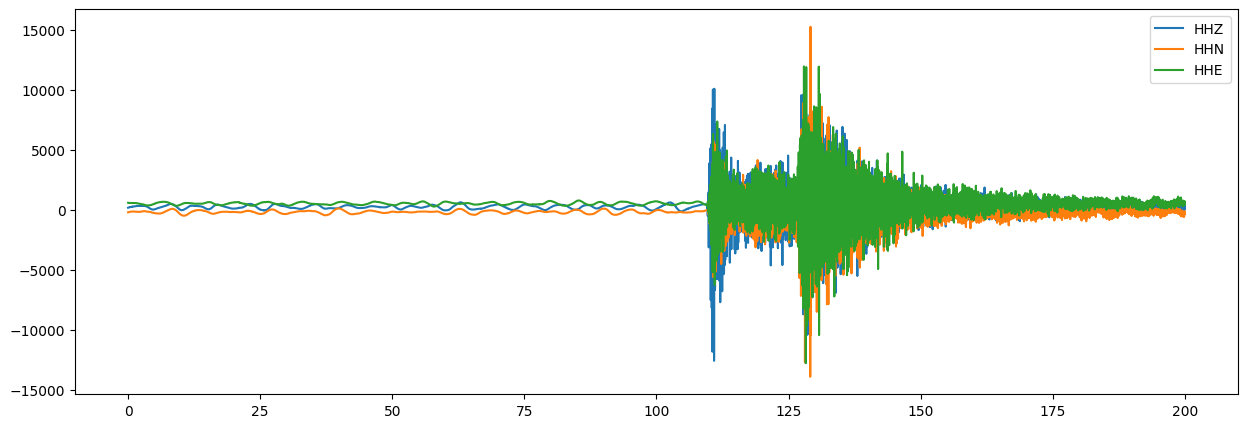

In [8]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
import matplotlib.pyplot as plt

client = Client("GFZ")

t = UTCDateTime("2007/01/02 05:48:50")
stream = client.get_waveforms(
    network="CX",
    station="PB01",
    location="*",
    channel="HH?",
    starttime=t - 100,
    endtime=t + 100,
)

fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(111)
for i in range(3):
    ax.plot(stream[i].times(), stream[i].data, label=stream[i].stats.channel)
ax.legend()

In [11]:
annotations = model.annotate(stream)
print(annotations)

3 Trace(s) in Stream:
CX.PB01..PhaseNet_N | 2007-01-02T05:47:12.498392Z - 2007-01-02T05:50:27.498392Z | 100.0 Hz, 19501 samples
CX.PB01..PhaseNet_P | 2007-01-02T05:47:12.498392Z - 2007-01-02T05:50:27.498392Z | 100.0 Hz, 19501 samples
CX.PB01..PhaseNet_S | 2007-01-02T05:47:12.498392Z - 2007-01-02T05:50:27.498392Z | 100.0 Hz, 19501 samples


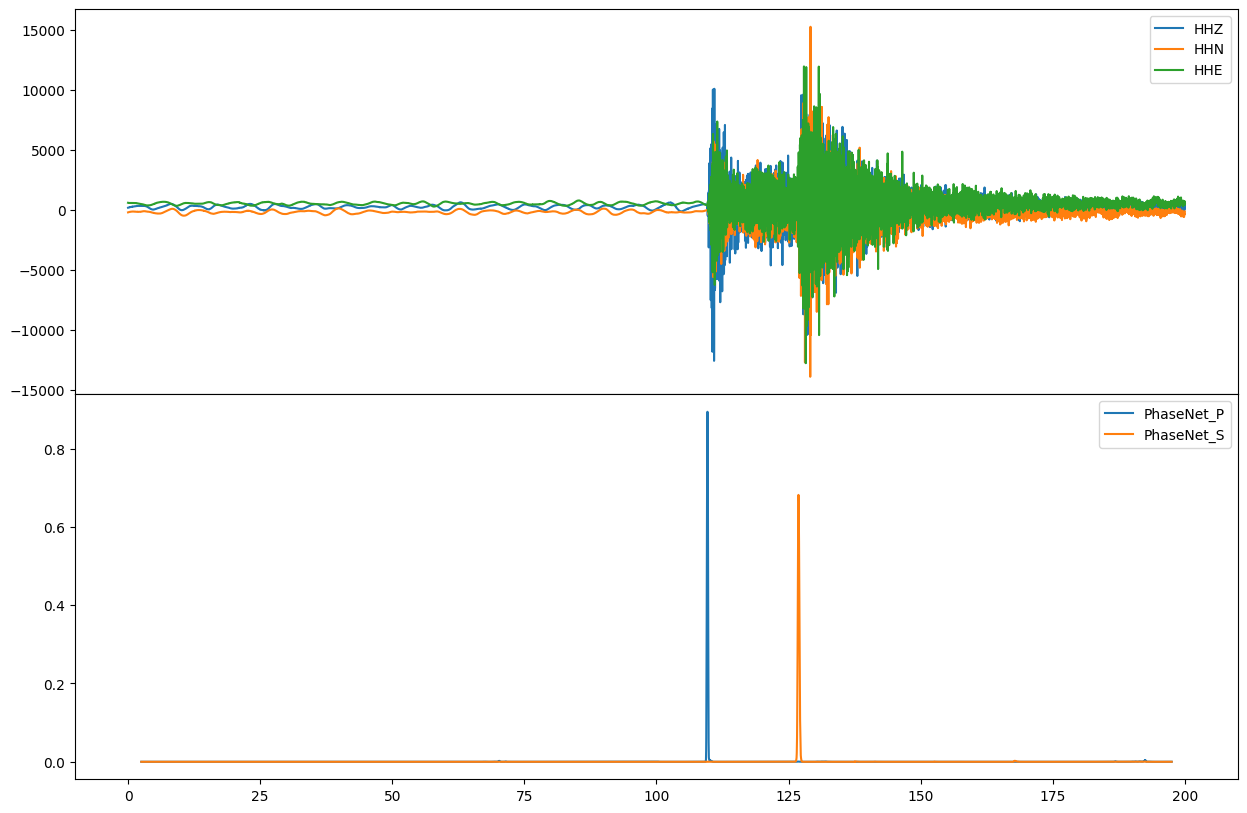

In [12]:
fig = plt.figure(figsize=(15, 10))
axs = fig.subplots(2, 1, sharex=True, gridspec_kw={"hspace": 0})

offset = annotations[0].stats.starttime - stream[0].stats.starttime
for i in range(3):
    axs[0].plot(stream[i].times(), stream[i].data, label=stream[i].stats.channel)
    if annotations[i].stats.channel[-1] != "N":  # Do not plot noise curve
        axs[1].plot(
            annotations[i].times() + offset,
            annotations[i].data,
            label=annotations[i].stats.channel,
        )

axs[0].legend()
axs[1].legend()

In [13]:
annotations = model.annotate(stream, overlap=2000)
print(annotations)

3 Trace(s) in Stream:
CX.PB01..PhaseNet_N | 2007-01-02T05:47:12.498392Z - 2007-01-02T05:50:27.498392Z | 100.0 Hz, 19501 samples
CX.PB01..PhaseNet_P | 2007-01-02T05:47:12.498392Z - 2007-01-02T05:50:27.498392Z | 100.0 Hz, 19501 samples
CX.PB01..PhaseNet_S | 2007-01-02T05:47:12.498392Z - 2007-01-02T05:50:27.498392Z | 100.0 Hz, 19501 samples


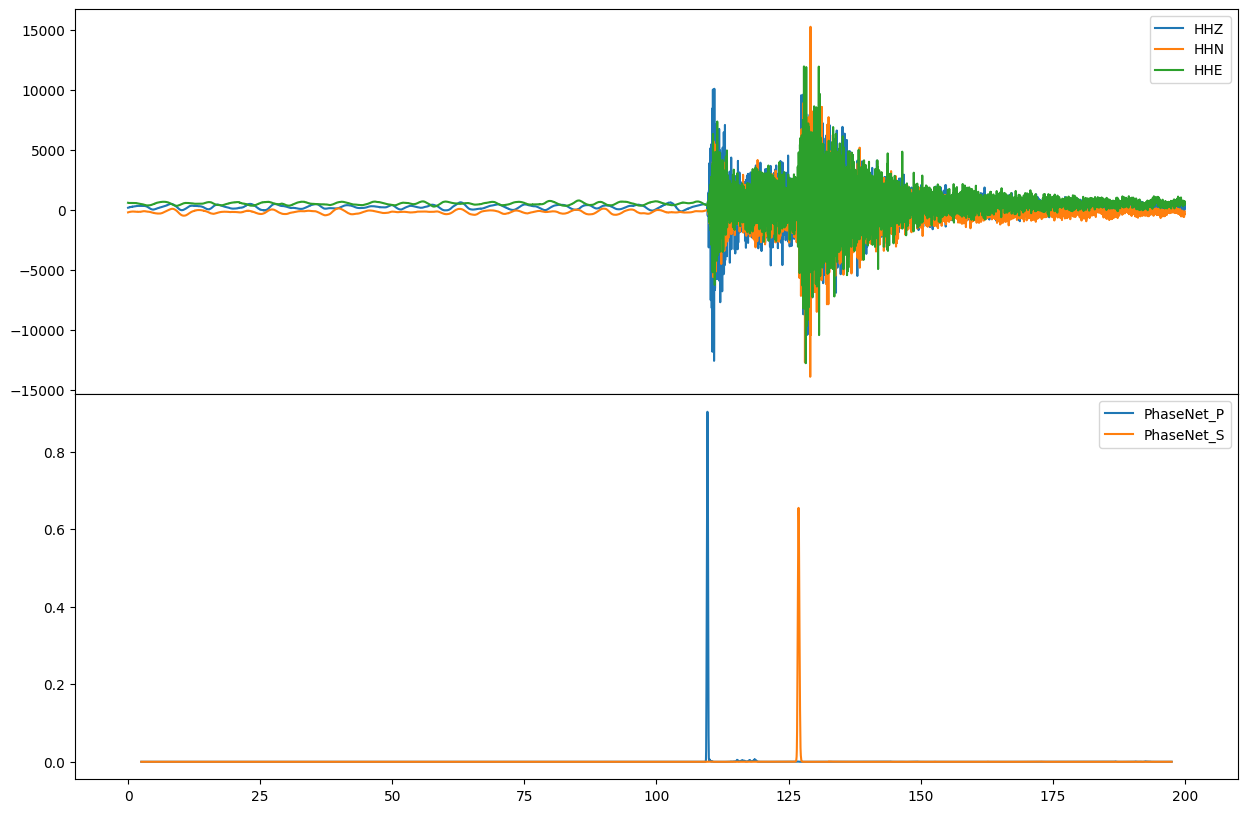

In [14]:
fig = plt.figure(figsize=(15, 10))
axs = fig.subplots(2, 1, sharex=True, gridspec_kw={"hspace": 0})

offset = annotations[0].stats.starttime - stream[0].stats.starttime
for i in range(3):
    axs[0].plot(stream[i].times(), stream[i].data, label=stream[i].stats.channel)
    if annotations[i].stats.channel[-1] != "N":  # Do not plot noise curve
        axs[1].plot(
            annotations[i].times() + offset,
            annotations[i].data,
            label=annotations[i].stats.channel,
        )

axs[0].legend()
axs[1].legend()

In [15]:
output = model.classify(stream, P_threshold=0.5, S_threshold=0.5)
print(output)

ClassifyOutput(creator='PhaseNet', picks=PickList with 2 entries:

CX.PB01.	2007-01-02T05:48:59.648392Z	P
CX.PB01.	2007-01-02T05:49:16.868392Z	S)


In [16]:
print(output.picks)

PickList with 2 entries:

CX.PB01.	2007-01-02T05:48:59.648392Z	P
CX.PB01.	2007-01-02T05:49:16.868392Z	S


In [17]:
model = sbm.EQTransformer.from_pretrained("stead")
print(model.weights_docstring)

Downloading: 100%|██████████| 1.52M/1.52M [00:00<00:00, 1.93MB/s]


Model trained on STEAD for 100 epochs with a learning rate of 0.001.
Threshold selected for optimal F1 score on in-domain evaluation. Depending on the target region, the thresholds might need to be adjusted.
When using this model, please reference the SeisBench publications listed at https://github.com/seisbench/seisbench

Jannes Münchmeyer, Jack Woollam (munchmej@gfz-potsdam.de, jack.woollam@kit.edu)


3 Trace(s) in Stream:
CX.PB01..EQTransformer_Detection | 2007-01-02T05:47:14.998392Z - 2007-01-02T05:50:24.998392Z | 100.0 Hz, 19001 samples
CX.PB01..EQTransformer_P         | 2007-01-02T05:47:14.998392Z - 2007-01-02T05:50:24.998392Z | 100.0 Hz, 19001 samples
CX.PB01..EQTransformer_S         | 2007-01-02T05:47:14.998392Z - 2007-01-02T05:50:24.998392Z | 100.0 Hz, 19001 samples


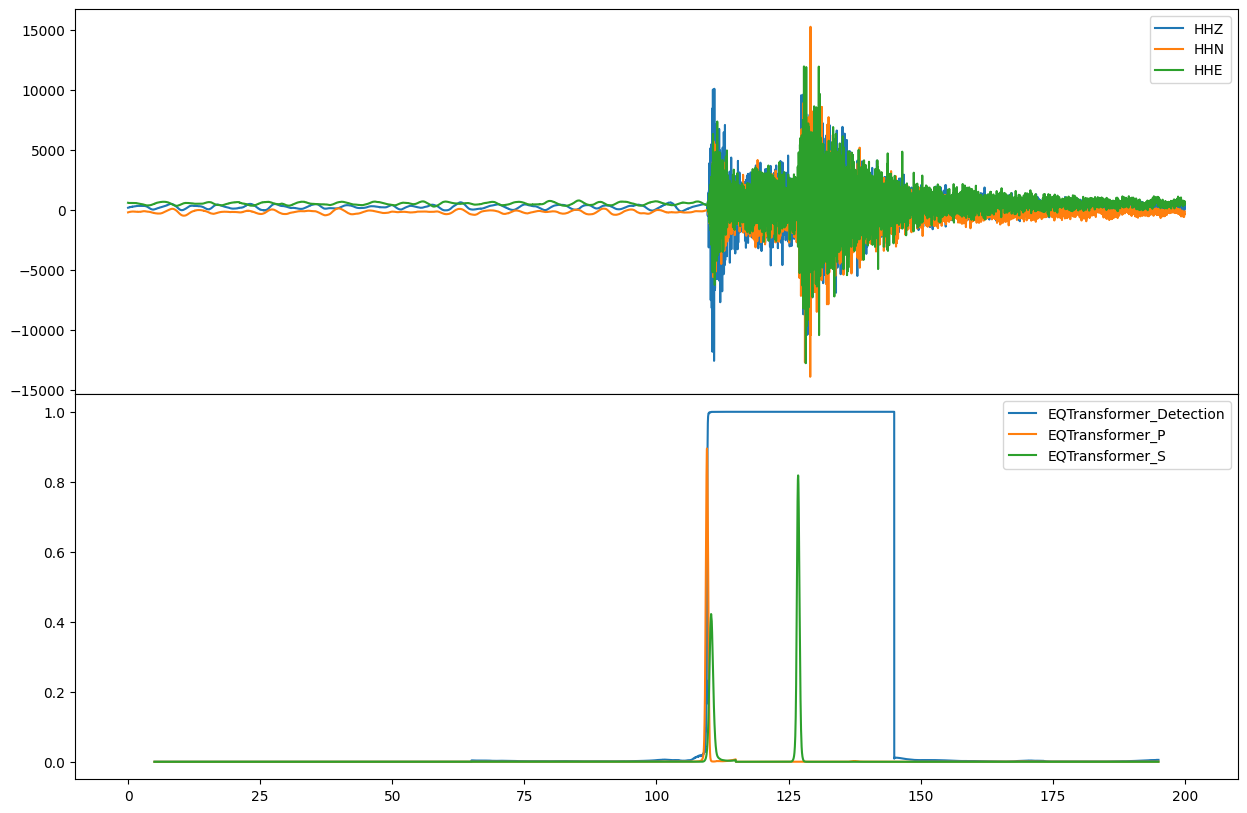

In [18]:
annotations = model.annotate(stream)
print(annotations)

fig = plt.figure(figsize=(15, 10))
axs = fig.subplots(2, 1, sharex=True, gridspec_kw={"hspace": 0})

offset = annotations[0].stats.starttime - stream[0].stats.starttime
for i in range(3):
    axs[0].plot(stream[i].times(), stream[i].data, label=stream[i].stats.channel)
    if annotations[i].stats.channel[-1] != "N":  # Do not plot noise curve
        axs[1].plot(
            annotations[i].times() + offset,
            annotations[i].data,
            label=annotations[i].stats.channel,
        )

axs[0].legend()
axs[1].legend()

In [19]:
output = model.classify(stream)
print(output)

ClassifyOutput(creator='EQTransformer', picks=PickList with 2 entries:

CX.PB01.	2007-01-02T05:48:59.548392Z	P
CX.PB01.	2007-01-02T05:49:16.808392Z	S, detections=DetectionList with 1 entries:

CX.PB01.	2007-01-02T05:48:59.618392Z	2007-01-02T05:49:34.988392Z)


In [20]:
model.to_preferred_device(verbose=True)

Model device: cpu


In [21]:
stream = client.get_waveforms(
    network="CX",
    station="*",
    location="*",
    channel="HH?",
    starttime=t - 100,
    endtime=t + 100,
)

output = model.classify(stream)
print(output.picks)
print(output.detections)

PickList with 12 entries:

CX.HMBCX.	2007-01-02T05:49:05.810002Z	P
CX.HMBCX.	2007-01-02T05:49:27.680002Z	S
CX.PATCX.	2007-01-02T05:49:06.279999Z	P
...
CX.PB03.	2007-01-02T05:49:26.208392Z	S
CX.PB04.	2007-01-02T05:49:35.298392Z	S
CX.PB05.	2007-01-02T05:49:15.198392Z	P
DetectionList with 11 entries:

CX.PB03.	2007-01-02T05:48:44.998392Z	2007-01-02T05:48:55.038392Z
CX.PB04.	2007-01-02T05:48:45.378392Z	2007-01-02T05:49:00.578392Z
CX.PB01.	2007-01-02T05:48:59.618392Z	2007-01-02T05:49:34.988392Z
...
CX.PSGCX.	2007-01-02T05:49:12.550005Z	2007-01-02T05:50:04.990005Z
CX.PB05.	2007-01-02T05:49:15.308392Z	2007-01-02T05:50:04.988392Z
CX.MNMCX.	2007-01-02T05:49:15.000004Z	2007-01-02T05:50:04.990004Z
